# BreaKHis Dataset Exploration and Initial Assessment 

## Notebook objective

This notebook explores the BreaKHis breast histopathology image dataset in order to understand its structure, class distribution, magnification levels, and potential issues that may affect model development. The purpose of this stage is to establish a clear data understanding before preprocessing and training.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

base_output_path = Path("/Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs")

figures_path = base_output_path / "figures"
metrics_path = base_output_path / "metrics"
reports_path = base_output_path / "reports"

figures_path.mkdir(parents=True, exist_ok=True)
metrics_path.mkdir(parents=True, exist_ok=True)
reports_path.mkdir(parents=True, exist_ok=True)

print("Figures:", figures_path)
print("Metrics:", metrics_path)
print("Reports:", reports_path)

Figures: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/figures
Metrics: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/metrics
Reports: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/reports


In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# plotting settings
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
dataset_path = Path("/Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/data/dataset_cancer_v1/dataset_cancer_v1")

print("Dataset exists:", dataset_path.exists())
print("Dataset path:", dataset_path)

Dataset exists: True
Dataset path: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/data/dataset_cancer_v1/dataset_cancer_v1


In [4]:
binary_path = dataset_path / "classificacao_binaria"

In [5]:
records = []

for magnification in ["40X", "100X", "200X", "400X"]:
    for label in ["benign", "malignant"]:
        folder = binary_path / magnification / label

        for img_path in folder.glob("*.png"):
            records.append({
                "filepath": str(img_path),
                "magnification": magnification,
                "label": label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
df.head()

Total images: 7909


,filepath,magnification,label
0,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,40X,benign
1,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,40X,benign
2,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,40X,benign
3,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,40X,benign
4,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,40X,benign


In [6]:
df["label"].value_counts()

label
malignant    5429
benign       2480
Name: count, dtype: int64

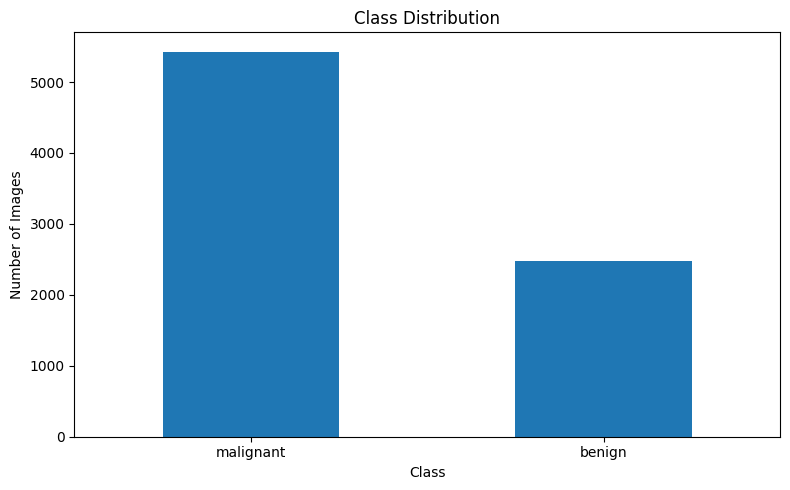

In [7]:
class_counts = df["label"].value_counts()

plt.figure(figsize=(8,5))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(figures_path / "figure_01_class_distribution.png", dpi=300)
plt.savefig(figures_path / "figure_01_class_distribution.pdf")

plt.show()

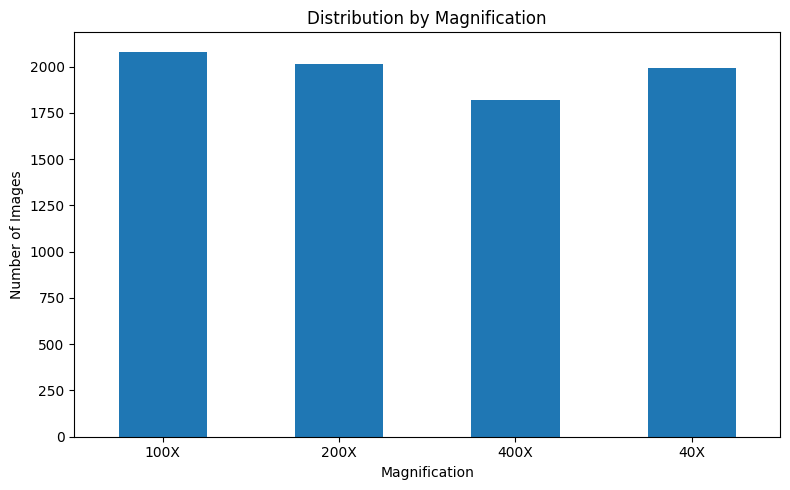

In [8]:
plt.figure(figsize=(8,5))

df["magnification"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution by Magnification")
plt.xlabel("Magnification")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(figures_path / "figure_02_magnification_distribution.png", dpi=300)
plt.savefig(figures_path / "figure_02_magnification_distribution.pdf")

plt.show()

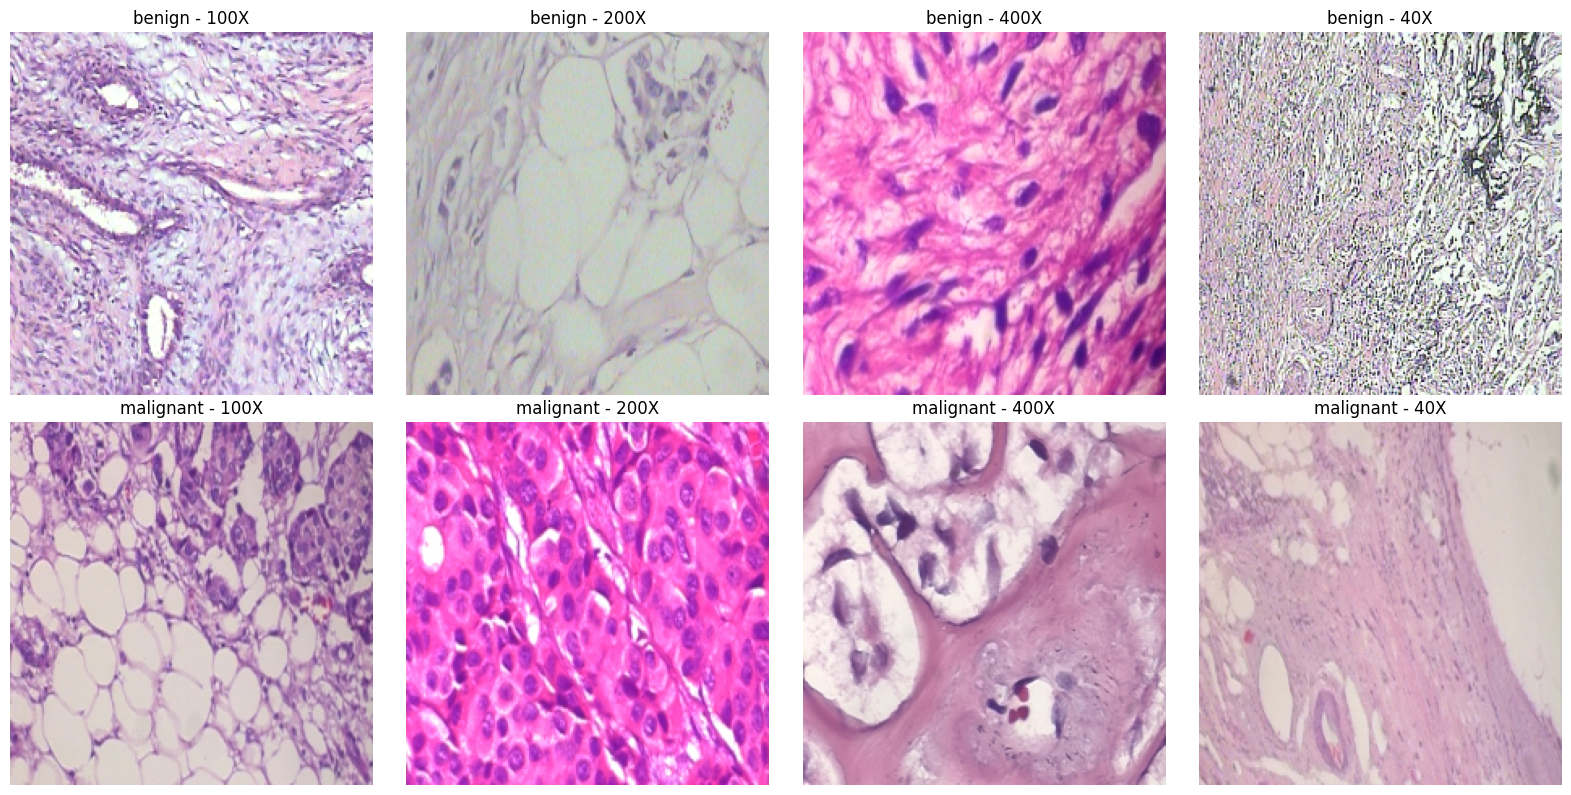

In [9]:
sample_images = df.groupby(["label", "magnification"]).first().reset_index()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (_, row) in zip(axes.flatten(), sample_images.iterrows()):
    img = Image.open(row["filepath"])
    ax.imshow(img)
    ax.set_title(f'{row["label"]} - {row["magnification"]}')
    ax.axis("off")

plt.tight_layout()
plt.savefig(figures_path / "figure_03_sample_images.png", dpi=300)
plt.savefig(figures_path / "figure_03_sample_images.pdf")

plt.show()

In [10]:
sample_paths = df["filepath"].sample(100, random_state=42)

means = []
stds = []

for path in sample_paths:
    img = np.array(Image.open(path)) / 255.0
    means.append(img.mean(axis=(0, 1)))
    stds.append(img.std(axis=(0, 1)))

mean_rgb = np.mean(means, axis=0)
std_rgb = np.mean(stds, axis=0)

print("Mean RGB:", mean_rgb)
print("Std RGB:", std_rgb)

Mean RGB: [0.79265212 0.62774458 0.76449277]
Std RGB: [0.10090955 0.1366441  0.08862125]


## Key Findings and Preprocessing Decision

The exploratory analysis confirmed that the BreaKHis binary dataset is suitable for convolutional neural network modelling.

The dataset contains 7,909 histopathology images across four magnification levels (40X, 100X, 200X, and 400X), with a moderate class imbalance favouring malignant samples.

Basic pixel statistics were calculated on a representative sample of 100 images. The resulting RGB channel means and standard deviations were:

- Mean: [0.793, 0.628, 0.764]
- Standard deviation: [0.101, 0.137, 0.089]

These values reflect the dominant H&E stain characteristics.

For preprocessing, two normalization strategies will be evaluated:

1. **dataset-specific normalization**, based on the calculated BreaKHis statistics
2. **ImageNet normalization**, to align with pretrained ResNet18 weights

This comparison will allow assessment of whether domain-specific normalization improves downstream classification performance.

## Train, Validation and Test Split Planning

A stratified split was created to preserve the benign and malignant class proportions across the train, validation, and test subsets. A 70/15/15 split was selected to provide sufficient training data while retaining separate validation and test sets for reliable evaluation.

In [11]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 5536
Validation size: 1186
Test size: 1187


In [12]:
train_df.to_csv(reports_path / "train_split.csv", index=False)
val_df.to_csv(reports_path / "val_split.csv", index=False)
test_df.to_csv(reports_path / "test_split.csv", index=False)

print("Splits saved successfully.")

Splits saved successfully.


In [13]:
print(list(reports_path.iterdir()))

[PosixPath('/Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/reports/train_split.csv'), PosixPath('/Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/reports/val_split.csv'), PosixPath('/Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/reports/test_split.csv')]
